In [13]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from scipy.integrate import solve_ivp

#<u>Problem 3</u>
#3. Duffing Oscillator with low acceleration

Consider the autonomous system:

dx/dt = r − αx − βx³

## Fixed Points

Equilibria satisfy:

r − αx − βx³ = 0
This is a cubic equation in x.  
Depending on the values of α, β, and r, the system can have:

- One real equilibrium
- Or three real equilibria

The number of equilibria changes as r varies, leading to possible bifurcations.

## Stability Analysis

Let:

f(x) = r − αx − βx³

r = αx + βx³

Thus, equilibria are given by the intersection of:

- y = αx + βx³  (a cubic curve)
- y = r          (a horizontal line)

The number of equilibria depends on the shape of the cubic, which is determined by α and β.


### Case 1: α > 0, β > 0

Here,

g(x) = αx + βx³

is a monotonically increasing function because:

g'(x) = α + 3βx² > 0  for all x.

Therefore:

- The cubic is strictly increasing.
- For every value of r, there is exactly one real equilibrium.
- No saddle-node bifurcation occurs.
- The equilibrium smoothly moves as r varies.

Since:

f'(x*) = −α − 3βx*² < 0,

the equilibrium is always stable.

Thus, the system has one globally stable equilibrium for all r.

### Case 2: α > 0, β < 0

Now,

g(x) = αx + βx³

is no longer monotonic.

Since β < 0, the cubic bends downward for large |x|.

In this case:

- The cubic has a local maximum and minimum.
- For certain ranges of r, three real equilibria exist.
- Two of them are stable and one is unstable.
- As r increases or decreases past critical values, two equilibria collide and disappear.

This corresponds to saddle-node bifurcations.

Thus, for α > 0 and β < 0, the system can exhibit bistability and saddle-node bifurcations.

### Case 3: α < 0, β > 0

Now the linear term is destabilizing near x = 0.

The cubic term stabilizes large |x|.

In this case:

- For r = 0, the system becomes symmetric.
- The system may exhibit a pitchfork-type bifurcation structure.
- The equilibrium at x = 0 can change stability as parameters vary.

The competition between the destabilizing linear term and stabilizing cubic term leads to symmetry-breaking behavior.
### Case 4: α < 0, β < 0
Same as Case 1 just the function will be strictly decreasing, and will show no bifurcation.

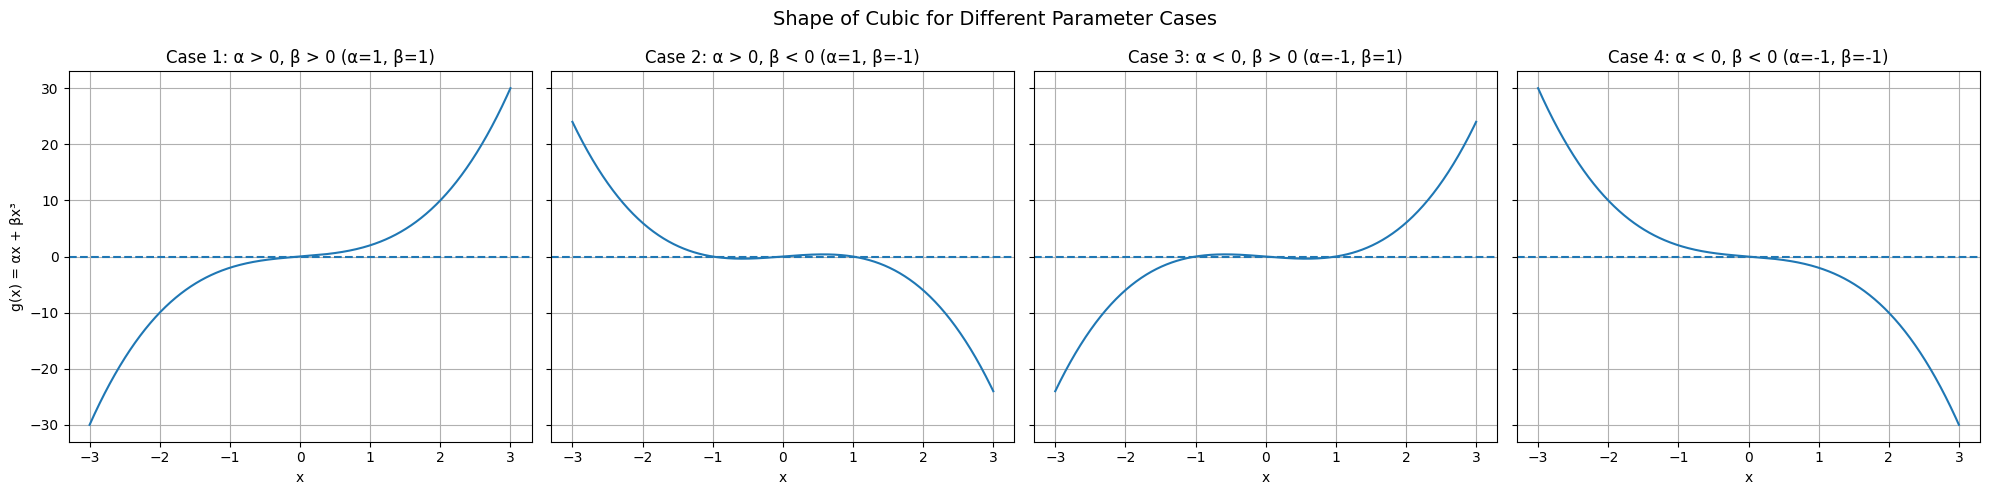

In [26]:
x = np.linspace(-3, 3, 500)

cases = [
    {"alpha": 1,  "beta": 1,  "title": "Case 1: α > 0, β > 0 (α=1, β=1)"},
    {"alpha": 1,  "beta": -1, "title": "Case 2: α > 0, β < 0 (α=1, β=-1)"},
    {"alpha": -1, "beta": 1,  "title": "Case 3: α < 0, β > 0 (α=-1, β=1)"},
    {"alpha": -1, "beta": -1, "title": "Case 4: α < 0, β < 0 (α=-1, β=-1)"}
]

fig, axes = plt.subplots(1, 4, figsize=(20,5), sharey=True)

for idx, case in enumerate(cases):
    alpha = case["alpha"]
    beta = case["beta"]
    g = alpha*x + beta*x**3

    axes[idx].plot(x, g)
    axes[idx].axhline(0, linestyle='--')
    axes[idx].set_title(case["title"])
    axes[idx].set_xlabel("x")
    axes[idx].grid(True)

axes[0].set_ylabel("g(x) = αx + βx³")
plt.suptitle("Shape of Cubic for Different Parameter Cases", fontsize=14)
plt.tight_layout()
plt.show()


## Physical Background of the Duffing Oscillator

The equation  

dx/dt = r − αx − βx³  

is a simplified, first-order version of the Duffing oscillator, which originates from the study of nonlinear forced oscillators in a viscous medium. In its classical second-order form, the Duffing equation models a mass attached to a nonlinear spring with damping and external forcing. It is widely used in mechanical vibrations, electrical circuits, structural engineering, and even in modeling climate and biological systems.

The cubic term (x³) arises from nonlinear restoring forces in real physical systems. In an ideal spring (Hooke’s law), the restoring force is proportional to displacement (linear term). However, for large deformations, many materials do not obey perfect linearity. The restoring force then contains higher-order corrections, and the leading nonlinear correction is often cubic. Thus, the force becomes proportional to x + βx³. This cubic term accounts for “hardening” behavior (β > 0), where stiffness increases with displacement, or “softening” behavior (β < 0), where stiffness decreases with displacement.

Physically, the presence of the x³ term allows the system to exhibit multiple equilibria, bistability, and sudden transitions as parameters change. This explains why the Duffing oscillator is a fundamental model in nonlinear dynamics: it captures real-world phenomena such as snap-through instabilities, hysteresis, and bifurcations, which cannot be described by purely linear systems.


We have added a slider for all the three cases, to show the bifurcation graphically.

In [27]:
alpha = 1
beta = 1

def plot_case1(r):
    x = np.linspace(-3, 3, 500)
    g = alpha*x + beta*x**3

    plt.figure(figsize=(8,6))
    plt.plot(x, g, label="y = x + x³")
    plt.axhline(y=r, color='black', linestyle='--', label=f"y = {r}")

    # Solve x^3 + x - r = 0
    coeffs = [1, 0, 1, -r]
    roots = np.roots(coeffs)

    xe = np.real(roots[np.isreal(roots)][0])

    plt.scatter([xe], [r], color='red', zorder=5, label="Equilibrium")

    plt.title("Case 1: α = 1, β = 1 (Monotonic cubic)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_case1, r=(-3.0, 3.0, 0.1));


interactive(children=(FloatSlider(value=0.0, description='r', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

In [28]:
alpha = 1
beta = -1

def plot_case2(r):
    x = np.linspace(-3, 3, 500)
    g = alpha*x + beta*x**3   # x - x^3

    plt.figure(figsize=(8,6))
    plt.plot(x, g, label="y = x - x³")
    plt.axhline(y=r, color='red', linestyle='--', label=f"y = {r}")
    coeffs = [1, 0, -1, r]
    roots = np.roots(coeffs)
    real_roots = np.real(roots[np.isreal(roots)])

    for xe in real_roots:
        plt.scatter(xe, r, color='black', zorder=5)

    plt.title("Case 2: α = 1, β = -1 (Saddle-Node structure)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_case2, r=(-3.0, 3.0, 0.1));


interactive(children=(FloatSlider(value=0.0, description='r', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

In [29]:
alpha = -1
beta = 1

def plot_case3(r):
    x = np.linspace(-3, 3, 500)
    g = alpha*x + beta*x**3   # -x + x^3

    plt.figure(figsize=(8,6))
    plt.plot(x, g, label="y = -x + x³")
    plt.axhline(y=r, color='black', linestyle='--', label=f"y = {r}")

    # Solve x^3 - x - r = 0
    coeffs = [1, 0, -1, -r]
    roots = np.roots(coeffs)

    # Keep only real roots
    real_roots = np.real(roots[np.isreal(roots)])

    for xe in real_roots:
        plt.scatter(xe, r, color='red', zorder=5)

    plt.title("Case 3: α = -1, β = 1 (Pitchfork bifurcation)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_case3, r=(-3.0, 3.0, 0.1));

interactive(children=(FloatSlider(value=0.0, description='r', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

In [31]:
alpha = -1
beta = -1

def plot_case4(r):
    x = np.linspace(-3, 3, 500)
    g = alpha*x + beta*x**3

    plt.figure(figsize=(8,6))
    plt.plot(x, g, label="y = -x - x³")

    coeffs = [1, 0, 1, r]
    roots = np.roots(coeffs)

    xe = np.real(roots[np.isreal(roots)][0])

    plt.scatter(xe, r, color='black', zorder=5, label="Equilibrium")

    plt.title("Case 4: α = -1, β = -1 (Single unstable equilibrium)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_case4, r=(-3.0, 3.0, 0.1));

interactive(children=(FloatSlider(value=0.0, description='r', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

##Conclusion

We analyzed the Duffing-type system

dx/dt = r − αx − βx³

by studying its equilibrium condition

r = αx + βx³

and examining how the number and stability of equilibria change as the parameter r varies.

The qualitative behavior of the system depends strongly on the signs of α and β:

- When α > 0 and β > 0, the cubic function is monotonic. The system has exactly one equilibrium for all values of r, and no saddle-node bifurcation occurs. The equilibrium moves smoothly as r changes.

- When α > 0 and β < 0, the cubic has turning points. For certain ranges of r, three equilibria exist. As r crosses critical values, two equilibria collide and disappear. This is characteristic of a saddle-node bifurcation.

- When α < 0 and β > 0, the system exhibits symmetry-breaking behavior. The equilibrium at the origin can change stability, and multiple equilibria may exist depending on r. This leads to pitchfork-like bifurcation structures.

Thus, the Duffing-type system demonstrates how nonlinear terms, particularly the cubic term, fundamentally alter system dynamics. Depending on parameter values, the system can exhibit single steady states, bistability, saddle-node bifurcations, or symmetry-breaking transitions. This highlights the importance of nonlinear effects in real physical and engineering systems.


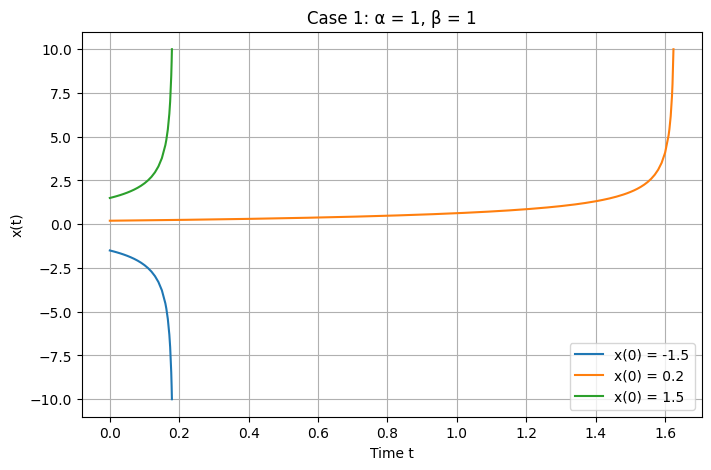

In [38]:
alpha = 1
beta = 1
r = 0

t_span = (0, 5)
ics = [-1.5, 0.2, 1.5]

def f(t, x):
    return alpha*x + beta*x**3 + r

def blowup(t, x):
    return 10 - abs(x[0])

blowup.terminal = True

plt.figure(figsize=(8,5))

for x0 in ics:
    sol = solve_ivp(
        f, t_span, [x0],
        method="Radau",
        max_step=0.01,
        events=blowup
    )
    plt.plot(sol.t, sol.y[0], label=f"x(0) = {x0}")

plt.title("Case 1: α = 1, β = 1")
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


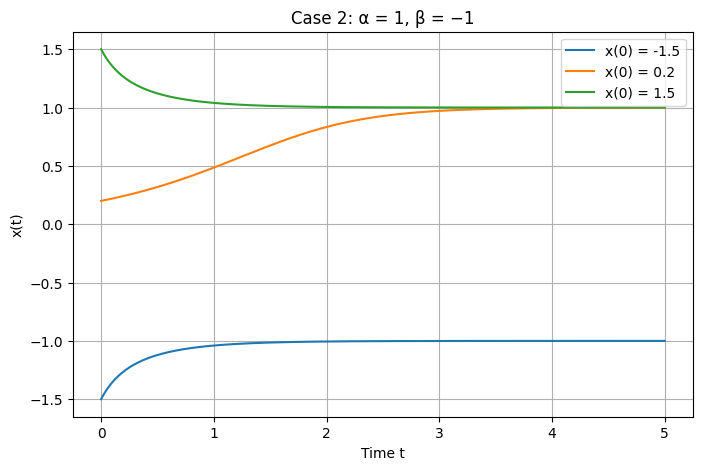

In [35]:
alpha = 1
beta = -1
r = 0

def f(t, x):
    return alpha*x + beta*x**3 + r
def blowup(t, x):
    return 10 - abs(x[0])

blowup.terminal = True

plt.figure(figsize=(8,5))

for x0 in ics:
    sol = solve_ivp(
        f, t_span, [x0],
        method="Radau",
        max_step=0.01,
        events=blowup
    )
    plt.plot(sol.t, sol.y[0], label=f"x(0) = {x0}")

plt.title("Case 2: α = 1, β = −1")
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


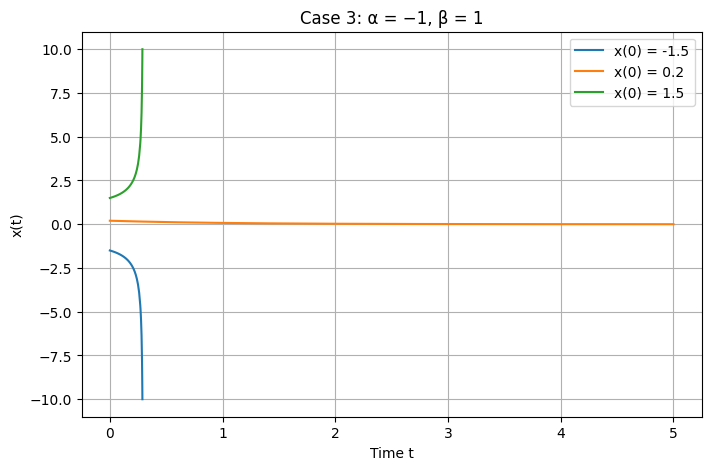

In [36]:
alpha = -1
beta = 1
r = 0

def f(t, x):
    return alpha*x + beta*x**3 + r
def blowup(t, x):
    return 10 - abs(x[0])

blowup.terminal = True

plt.figure(figsize=(8,5))

for x0 in ics:
    sol = solve_ivp(
        f, t_span, [x0],
        method="Radau",
        max_step=0.01,
        events=blowup
    )
    plt.plot(sol.t, sol.y[0], label=f"x(0) = {x0}")

plt.title("Case 3: α = −1, β = 1")
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


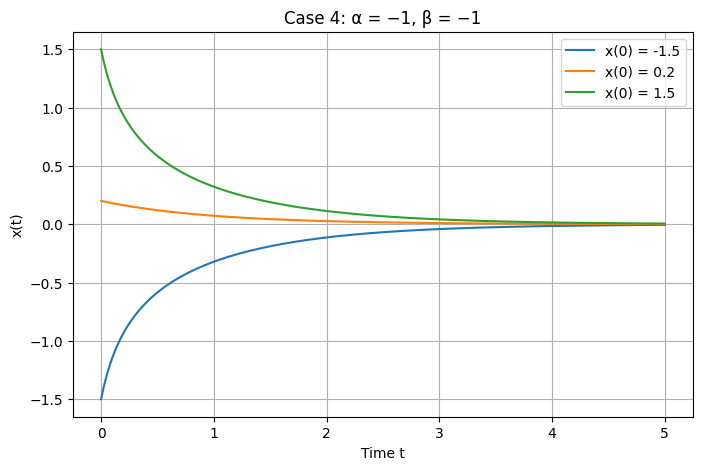

In [37]:
alpha = -1
beta = -1
r = 0

def f(t, x):
    return alpha*x + beta*x**3 + r
def blowup(t, x):
    return 10 - abs(x[0])

blowup.terminal = True
plt.figure(figsize=(8,5))

for x0 in ics:
    sol = solve_ivp(
        f, t_span, [x0],
        method="Radau",
        max_step=0.01,
        events=blowup
    )
    plt.plot(sol.t, sol.y[0], label=f"x(0) = {x0}")

plt.title("Case 4: α = −1, β = −1")
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


### Observations Based on Initial Conditions (x(0)) for the Four Cases

**Case 1: α = 1, β = 1 (Monotonic increasing cubic)**  
For different initial conditions, all trajectories move away from the equilibrium point. If the initial condition is positive, x(t) increases rapidly and diverges to large positive values. If the initial condition is negative, x(t) decreases further into negative values. Small differences in initial conditions lead to large differences in trajectories over time, indicating instability.




**Case 2: α = 1, β = −1 (Saddle-node structure)**  
The system’s behavior strongly depends on where the initial condition lies relative to the equilibrium points. Initial conditions close to the stable equilibrium move toward it as time increases. Initial conditions near the unstable equilibrium move away from it and eventually diverge. Thus, two nearby initial conditions can evolve very differently depending on which side of the unstable point they start from.

**Case 3: α = −1, β = 1 (Pitchfork-type behavior)**  
Initial conditions near the origin tend to move away from it, showing that the central equilibrium is unstable. Initial conditions that start slightly positive move toward the positive stable equilibrium, while those starting slightly negative move toward the negative stable equilibrium. This clearly demonstrates symmetry breaking, where the long-term state depends on the sign of the initial condition.

**Case 4: α = −1, β = −1 (Single stable equilibrium)**  
All initial conditions, whether positive or negative, eventually move toward the same equilibrium point. Differences in initial conditions only affect how fast the trajectory approaches equilibrium, not the final state. This shows strong stability, as the system forgets its initial condition over time.
